<a href="https://colab.research.google.com/github/silent-scientist/adtech-user-segmentation-kmeans/blob/main/notebook/adtech_user_segmentation_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This section generates a synthetic dataset to simulate ad-tech events such as impressions, clicks, add-to-cart actions, and purchases. The dataset includes various user behaviors, event types, categories, devices, and prices, along with user personas to add complexity to the data.

In [24]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

np.random.seed(42)

# Parameters
NUM_USERS = 5000
DAYS = 30

user_ids = [f"user_{i}" for i in range(NUM_USERS)]

event_types = ["impression", "click", "add_to_cart", "purchase"]
categories = ["electronics", "fashion", "grocery", "travel"]
devices = ["mobile", "desktop"]

# Assign user personas
personas = ["high_intent", "window_shopper", "ad_fatigued", "dormant", "deal_hunter"]
user_persona_map = {user: np.random.choice(personas, p=[0.2,0.25,0.2,0.2,0.15]) for user in user_ids}

data = []

start_date = datetime.now() - timedelta(days=DAYS)

for user in user_ids:
    persona = user_persona_map[user]

    num_days_active = np.random.randint(5, DAYS)

    for _ in range(num_days_active):
        day = start_date + timedelta(days=np.random.randint(0, DAYS))

        # base impressions
        if persona == "ad_fatigued":
            impressions = np.random.randint(20, 50)
        elif persona == "high_intent":
            impressions = np.random.randint(5, 20)
        else:
            impressions = np.random.randint(5, 30)

        for _ in range(impressions):
            event_time = day + timedelta(minutes=np.random.randint(0, 1440))

            category = random.choice(categories)
            device = random.choice(devices)

            # impression
            data.append([user, event_time, "impression", category, device, 0])

            # click probability
            if persona == "high_intent":
                click_prob = 0.3
            elif persona == "window_shopper":
                click_prob = 0.25
            elif persona == "ad_fatigued":
                click_prob = 0.02
            elif persona == "deal_hunter":
                click_prob = 0.35
            else:
                click_prob = 0.05

            if np.random.rand() < click_prob:
                data.append([user, event_time, "click", category, device, 0])

                # add to cart
                if np.random.rand() < 0.5:
                    data.append([user, event_time, "add_to_cart", category, device, 0])

                    # purchase probability
                    if persona == "high_intent":
                        purchase_prob = 0.5
                    elif persona == "deal_hunter":
                        purchase_prob = 0.4
                    else:
                        purchase_prob = 0.1

                    if np.random.rand() < purchase_prob:
                        price = np.random.randint(10, 500)
                        data.append([user, event_time, "purchase", category, device, price])

df = pd.DataFrame(data, columns=[
    "user_id", "event_time", "event_type", "category", "device", "price"
])

df.to_csv("adtech_events.csv", index=False)

print("Dataset created:", df.shape)

After generating the synthetic data, this cell performs an initial exploration of the DataFrame, displaying the first few rows, the counts of each event type, and the mean price for each event type.

In [25]:
df.head()
df['event_type'].value_counts()
df.groupby('event_type')['price'].mean()

,price
event_type,
add_to_cart,0.000000
click,0.000000
impression,0.000000
purchase,255.056386


This section focuses on performing basic aggregations on the event data. It converts the 'event_time' column to datetime objects and then pivots the data to count the occurrences of each event type ('impression', 'click', 'add_to_cart', 'purchase') for each user. The columns are renamed for clarity.

In [26]:
df['event_time'] = pd.to_datetime(df['event_time'])

agg = df.pivot_table(
    index='user_id',
    columns='event_type',
    values='event_time',
    aggfunc='count',
    fill_value=0
).reset_index()

agg.columns.name = None

agg = agg.rename(columns={
    'impression': 'impressions',
    'click': 'clicks',
    'add_to_cart': 'add_to_cart',
    'purchase': 'purchases'
})

This section calculates key funnel metrics, including Click-Through Rate (CTR) and Conversion Rate (CVR). CTR is calculated as clicks divided by impressions, and CVR is calculated as purchases divided by clicks. Any divisions by zero are handled by replacing them with NaN and then filling all NaN values with 0.

In [27]:
agg['CTR'] = agg['clicks'] / agg['impressions'].replace(0, np.nan)
agg['CVR'] = agg['purchases'] / agg['clicks'].replace(0, np.nan)

agg = agg.fillna(0)

This section extracts monetary features by calculating the total spend and average order value for each user based on their purchase events. It then merges these new features into the aggregated DataFrame.

In [28]:
spend = df[df['event_type'] == 'purchase'].groupby('user_id')['price'].agg([
    'sum', 'mean'
]).reset_index()

spend.columns = ['user_id', 'total_spend', 'avg_order_value']

agg = agg.merge(spend, on='user_id', how='left').fillna(0)

This section calculates the recency of user activity, defined as the number of days since the user's last event. It determines the latest event time across the entire dataset and then calculates the difference in days between this latest time and each user's last event time. This recency score is then merged into the aggregated DataFrame.

In [29]:
latest_time = df['event_time'].max()

recency = df.groupby('user_id')['event_time'].max().reset_index()
recency['recency_days'] = (latest_time - recency['event_time']).dt.days

agg = agg.merge(recency[['user_id', 'recency_days']], on='user_id')

This section introduces engagement features. It calculates the number of unique active days for each user and the average number of events per active day. These metrics provide insights into user activity levels and are merged into the main aggregated DataFrame.

In [30]:
# Active days
df['date'] = df['event_time'].dt.date

active_days = df.groupby('user_id')['date'].nunique().reset_index()
active_days.columns = ['user_id', 'active_days']

agg = agg.merge(active_days, on='user_id')

# Avg events per active day
total_events = df.groupby('user_id').size().reset_index(name='total_events')
agg = agg.merge(total_events, on='user_id')

agg['events_per_day'] = agg['total_events'] / agg['active_days']

This section defines an 'ad_fatigue_score' to estimate how saturated a user might be with impressions relative to their clicks. A higher score suggests more impressions with fewer clicks, potentially indicating fatigue. To prevent division by zero, 1 is added to the click count.

In [31]:
agg['ad_fatigue_score'] = agg['impressions'] / (agg['clicks'] + 1)

This section calculates the category entropy for each user, which measures the diversity of product categories a user interacts with. A higher entropy indicates broader exploration across categories. The entropy is calculated using `scipy.stats.entropy` and then merged into the main aggregated DataFrame.

In [32]:
from scipy.stats import entropy

def category_entropy(user_df):
    counts = user_df['category'].value_counts()
    return entropy(counts)

cat_entropy = df.groupby('user_id').apply(category_entropy).reset_index()
cat_entropy.columns = ['user_id', 'category_entropy']

agg = agg.merge(cat_entropy, on='user_id')

/tmp/ipykernel_8539/1991294905.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_entropy = df.groupby('user_id').apply(category_entropy).reset_index()


This cell prepares the final DataFrame (`final_df`) by making a copy of the aggregated features. It then prints the shape of the DataFrame and displays its first few rows to provide a summary of the engineered features before clustering.

In [33]:
final_df = agg.copy()

print(final_df.shape)
final_df.head()

(5000, 15)


,user_id,add_to_cart,clicks,impressions,purchases,CTR,CVR,total_spend,avg_order_value,recency_days,active_days,total_events,events_per_day,ad_fatigue_score,category_entropy
0,user_0,60,108,428,7,0.252336,0.064815,1990.0,284.285714,4,24,603,25.12500,3.926606,1.379869
1,user_1,34,63,144,11,0.437500,0.174603,2860.0,260.000000,3,15,252,16.80000,2.250000,1.360865
2,user_10,41,85,296,21,0.287162,0.247059,5997.0,285.571429,5,23,443,19.26087,3.441860,1.374585
3,user_100,54,110,361,32,0.304709,0.290909,7971.0,249.093750,0,25,557,22.28000,3.252252,1.370465
4,user_1000,58,95,277,26,0.342960,0.273684,6557.0,252.192308,0,25,456,18.24000,2.885417,1.379888


This cell provides a statistical summary of the `final_df` using the `describe()` method. This helps in understanding the distribution, central tendency, and spread of each feature in the dataset, which is useful for identifying outliers or understanding feature ranges before scaling and clustering.

In [35]:
final_df.describe()


,add_to_cart,clicks,impressions,purchases,CTR,CVR,total_spend,avg_order_value,recency_days,active_days,total_events,events_per_day,ad_fatigue_score,category_entropy
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25.48660,50.869600,331.19380,7.360000,0.189560,0.113701,1877.215000,196.373078,1.580600,19.653400,414.910000,20.306644,15.786856,1.377864
std,21.61408,42.577421,202.07505,9.415462,0.131986,0.106059,2437.421942,131.104467,2.256396,5.484313,214.930329,7.331163,19.632522,0.010552
min,0.00000,0.000000,41.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,54.000000,5.250000,2.185185,1.245450
25%,7.00000,15.000000,183.00000,1.000000,0.041667,0.022161,70.000000,62.750000,0.000000,16.000000,241.000000,14.916667,3.258065,1.375840
50%,18.00000,36.000000,296.00000,3.000000,0.240327,0.074074,696.000000,232.485294,1.000000,21.000000,395.000000,18.952381,4.082079,1.381230
75%,41.00000,83.000000,423.00000,12.000000,0.301594,0.200000,2939.750000,281.144481,2.000000,24.000000,541.250000,24.500000,21.964286,1.384050
max,118.00000,221.000000,1105.00000,56.000000,0.444444,0.588235,14709.000000,499.000000,20.000000,31.000000,1131.000000,51.409091,226.000000,1.386267


This cell prepares the features for clustering by dropping the `user_id` column, as it is an identifier and not a predictive feature. It then displays the column names of the resulting `features` DataFrame to confirm the set of features that will be used for clustering.

In [36]:
features = final_df.drop(columns=['user_id'])

features.columns

Index(['add_to_cart', 'clicks', 'impressions', 'purchases', 'CTR', 'CVR',
       'total_spend', 'avg_order_value', 'recency_days', 'active_days',
       'total_events', 'events_per_day', 'ad_fatigue_score',
       'category_entropy'],
      dtype='object')

This section applies a log transformation to selected features (`total_spend`, `avg_order_value`, `impressions`, `clicks`). This is often done to reduce the skewness of data distributions and stabilize variance, which can improve the performance of clustering algorithms like K-Means. `np.log1p` is used to handle zero values gracefully (log(1+x)).

In [38]:
import numpy as np

log_features = features.copy()

cols_to_log = ['total_spend', 'avg_order_value', 'impressions', 'clicks']

for col in cols_to_log:
    log_features[col] = np.log1p(log_features[col])

This section standardizes the features using `StandardScaler`. Standardization transforms the data such that it has a mean of 0 and a standard deviation of 1. This is crucial for distance-based algorithms like K-Means, as it prevents features with larger scales from dominating the distance calculations.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(log_features)

This section implements the Elbow Method to determine the optimal number of clusters (K) for K-Means. It calculates the inertia (sum of squared distances of samples to their closest cluster center) for a range of K values and plots them. The 'elbow' point in the plot suggests a suitable K where the rate of decrease in inertia slows down significantly.

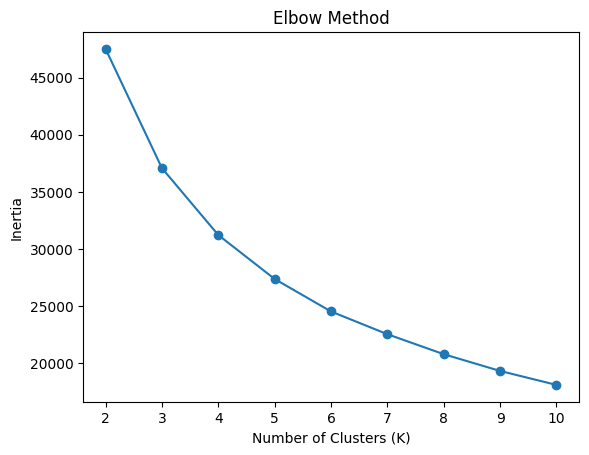

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

This section uses the Silhouette Score to evaluate the quality of clustering for different numbers of clusters (K). The silhouette score measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters. The scores are plotted against K to help identify the optimal number of clusters.

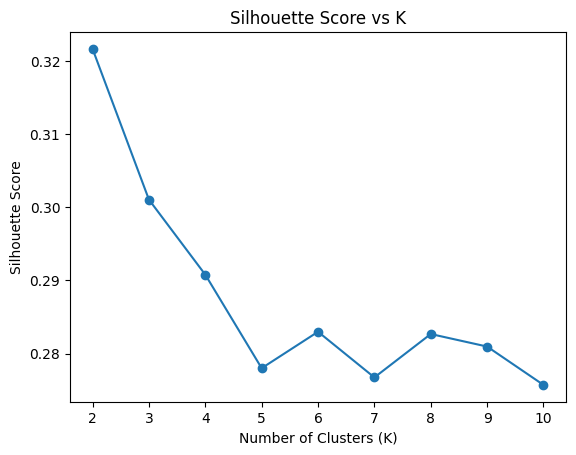

In [42]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    sil_scores.append(score)

plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

Based on the insights from the Elbow Method and Silhouette Score (though typically the elbow point might suggest a different K than the silhouette peak), this cell applies K-Means clustering with `n_clusters=5`. The resulting cluster assignments for each user are added as a new 'cluster' column to the `final_df`.

In [45]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
final_df['cluster'] = kmeans.fit_predict(scaled_data)


This cell counts the number of users assigned to each cluster. This provides an overview of the distribution of users across the identified segments.

In [46]:
final_df['cluster'].value_counts()

,count
cluster,
3,1257
1,1097
4,1062
2,847
0,737


This cell calculates the mean of all numerical features for each cluster, providing a summary of the characteristics that define each user segment. Rounding to two decimal places improves readability.

In [51]:
cluster_summary = final_df.groupby('cluster').mean(numeric_only=True).round(2)

cluster_summary

,add_to_cart,clicks,impressions,purchases,CTR,CVR,total_spend,avg_order_value,recency_days,active_days,total_events,events_per_day,ad_fatigue_score,category_entropy
cluster,,,,,,,,,,,,,,
0,7.03,14.09,695.23,0.72,0.02,0.06,181.25,134.40,1.08,22.16,717.07,32.09,50.57,1.38
1,51.52,102.58,311.93,22.86,0.33,0.23,5845.07,255.54,0.89,23.09,488.89,21.21,3.06,1.38
2,5.95,12.59,245.72,0.05,0.06,0.01,4.79,4.79,2.36,16.08,264.30,16.44,25.91,1.38
3,33.80,67.22,359.07,3.61,0.19,0.06,917.89,258.44,0.91,22.65,463.71,20.41,8.51,1.38
4,17.15,34.15,133.63,6.22,0.26,0.18,1584.38,257.60,2.80,13.67,191.15,14.16,5.33,1.37


This section assigns descriptive names to each cluster based on their summarized characteristics. These names ('Ad Fatigued', 'High Value', 'Dormant', 'Window Shoppers', 'Efficient Users') make the clusters more interpretable and actionable. The `final_df` is then updated with a new `cluster_name` column.

In [53]:
cluster_names = {
    0: "Ad Fatigued",
    1: "High Value",
    2: "Dormant",
    3: "Window Shoppers",
    4: "Efficient Users"
}

final_df['cluster_name'] = final_df['cluster'].map(cluster_names)

final_df

,user_id,add_to_cart,clicks,impressions,purchases,CTR,CVR,total_spend,avg_order_value,recency_days,active_days,total_events,events_per_day,ad_fatigue_score,category_entropy,cluster,cluster_name
0,user_0,60,108,428,7,0.252336,0.064815,1990.0,284.285714,4,24,603,25.125000,3.926606,1.379869,3,Window Shoppers
1,user_1,34,63,144,11,0.437500,0.174603,2860.0,260.000000,3,15,252,16.800000,2.250000,1.360865,4,Efficient Users
2,user_10,41,85,296,21,0.287162,0.247059,5997.0,285.571429,5,23,443,19.260870,3.441860,1.374585,1,High Value
3,user_100,54,110,361,32,0.304709,0.290909,7971.0,249.093750,0,25,557,22.280000,3.252252,1.370465,1,High Value
4,user_1000,58,95,277,26,0.342960,0.273684,6557.0,252.192308,0,25,456,18.240000,2.885417,1.379888,1,High Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,user_995,49,105,365,26,0.287671,0.247619,7231.0,278.115385,1,28,545,19.464286,3.443396,1.377921,1,High Value
4996,user_996,19,37,112,8,0.330357,0.216216,2250.0,281.250000,12,8,176,22.000000,2.947368,1.333459,4,Efficient Users
4997,user_997,49,95,306,24,0.310458,0.252632,4918.0,204.916667,0,27,474,17.555556,3.187500,1.375606,1,High Value
4998,user_998,24,40,114,5,0.350877,0.125000,1580.0,316.000000,1,15,183,12.200000,2.780488,1.380218,4,Efficient Users


This section assesses the stability of the K-Means clustering algorithm. It runs K-Means multiple times with different random initializations (`random_state`) and calculates the Adjusted Rand Index (ARI) between the resulting cluster assignments. A high ARI score indicates that the clustering results are consistent and not overly sensitive to the initial conditions.

In [54]:
## Code Stability
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

runs = 5
labels_list = []

for i in range(runs):
    kmeans = KMeans(n_clusters=5, random_state=i, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    labels_list.append(labels)

# Compare pairwise similarity
stability_scores = []

for i in range(runs):
    for j in range(i+1, runs):
        score = adjusted_rand_score(labels_list[i], labels_list[j])
        stability_scores.append(score)

print("Stability Scores:", stability_scores)
print("Average Stability:", sum(stability_scores)/len(stability_scores))

Stability Scores: [0.9994259165374175, 0.9994259165374175, 0.9994259165374175, 0.9994259165374175, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Average Stability: 0.999770366614967


This section uses Principal Component Analysis (PCA) to reduce the dimensionality of the scaled data to two components, allowing for a 2D visualization of the clusters. Users are plotted on a scatter plot, with points colored according to their assigned cluster. This helps visually inspect the separation and compactness of the clusters.

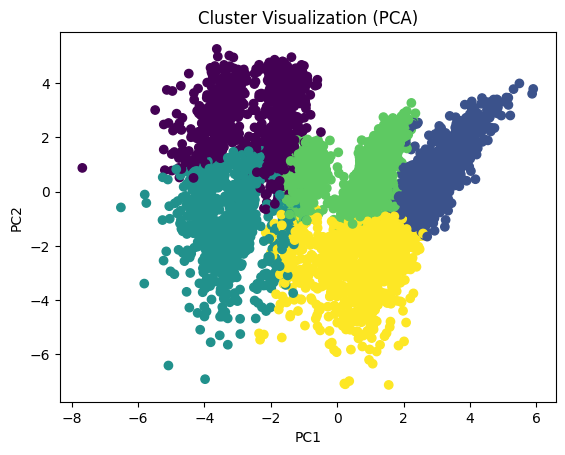

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_data)

plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1], c=final_df['cluster'])
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

This cell generates a bar plot to compare the average CTR, CVR, and total spend across different clusters. This visualization makes it easy to identify which clusters excel or lag in these key performance indicators, aiding in targeted strategy development.

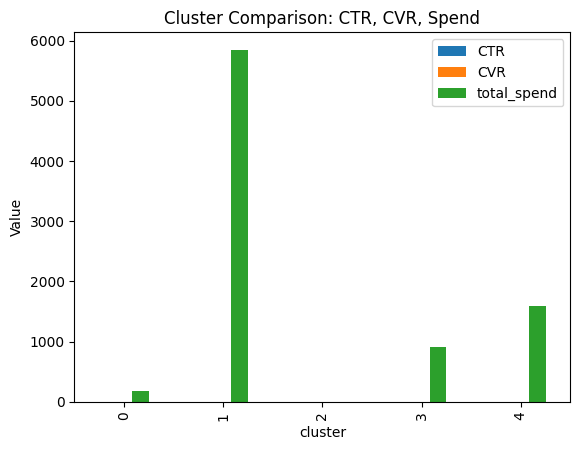

In [56]:
cluster_summary[['CTR', 'CVR', 'total_spend']].plot(kind='bar')
plt.title("Cluster Comparison: CTR, CVR, Spend")
plt.ylabel("Value")
plt.show()

This cell creates a box plot to visualize the distribution of 'total_spend' for each cluster. Box plots are excellent for showing the median, quartiles, and potential outliers within each cluster, providing a deeper understanding of the spending habits of different user segments.

<Figure size 640x480 with 0 Axes>

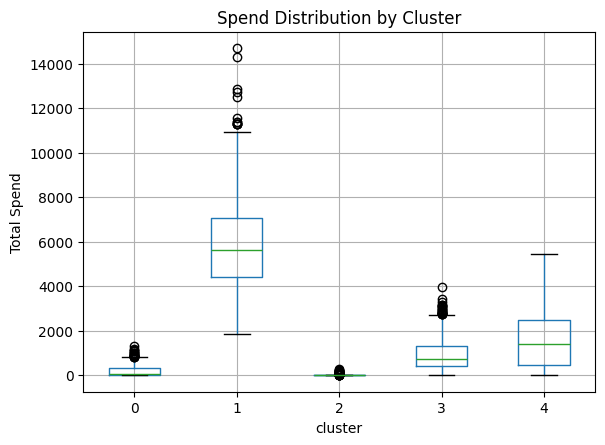

In [57]:
plt.figure()
final_df.boxplot(column='total_spend', by='cluster')
plt.title("Spend Distribution by Cluster")
plt.suptitle("")
plt.ylabel("Total Spend")
plt.show()